# Understanding WRMSSE (Weighted Root Mean Squared Scaled Error)

This notebook breaks down the WRMSSE metric step by step, showing how each component contributes to the final score. We'll use sample data and visualizations to build intuition about this complex but important evaluation metric used in the M5 forecasting competition.

## 1. Import Required Libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sys

# Import our WRMSSE module
sys.path.insert(0, '../src')
from wrmsse import wrmsse, compute_scale, compute_weights, compute_rmsse

# Set plot style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 5)
np.random.seed(42)

## 2. Load and Prepare Sample Data

Let's create sample time series data for 4 different items with varying characteristics:
- **Item 1**: High volume, stable sales
- **Item 2**: High volume, volatile sales
- **Item 3**: Low volume, stable sales
- **Item 4**: Low volume, volatile sales

In [3]:
# Create sample data
n_train = 100
n_test = 20

# Item 1: High volume, stable (mean=50, std=5)
item1_train = np.random.normal(50, 5, n_train)
item1_test = np.random.normal(50, 5, n_test)
item1_pred = item1_test + np.random.normal(0, 2, n_test)  # Forecast with noise

# Item 2: High volume, volatile (mean=50, std=15)
item2_train = np.random.normal(50, 15, n_train)
item2_test = np.random.normal(50, 15, n_test)
item2_pred = item2_test + np.random.normal(0, 3, n_test)

# Item 3: Low volume, stable (mean=10, std=2)
item3_train = np.random.normal(10, 2, n_train)
item3_test = np.random.normal(10, 2, n_test)
item3_pred = item3_test + np.random.normal(0, 1, n_test)

# Item 4: Low volume, volatile (mean=10, std=5)
item4_train = np.random.normal(10, 5, n_train)
item4_test = np.random.normal(10, 5, n_test)
item4_pred = item4_test + np.random.normal(0, 2, n_test)

# Ensure non-negative values
y_train = np.array([np.maximum(item1_train, 0), 
                    np.maximum(item2_train, 0),
                    np.maximum(item3_train, 0),
                    np.maximum(item4_train, 0)])

y_test = np.array([np.maximum(item1_test, 0),
                   np.maximum(item2_test, 0),
                   np.maximum(item3_test, 0),
                   np.maximum(item4_test, 0)])

y_pred = np.array([np.maximum(item1_pred, 0),
                   np.maximum(item2_pred, 0),
                   np.maximum(item3_pred, 0),
                   np.maximum(item4_pred, 0)])

# Create DataFrames for easier visualization
items = ['Item 1: High Vol, Stable', 'Item 2: High Vol, Volatile', 
         'Item 3: Low Vol, Stable', 'Item 4: Low Vol, Volatile']

print("Sample Data Summary:")
print(f"Training data shape: {y_train.shape}")
print(f"Test data shape: {y_test.shape}")
print("\nTraining data statistics:")
for i, item in enumerate(items):
    print(f"{item}: mean={y_train[i].mean():.2f}, std={y_train[i].std():.2f}, sum={y_train[i].sum():.2f}")

Sample Data Summary:
Training data shape: (4, 100)
Test data shape: (4, 20)

Training data statistics:
Item 1: High Vol, Stable: mean=49.48, std=4.52, sum=4948.08
Item 2: High Vol, Volatile: mean=51.68, std=14.95, sum=5167.81
Item 3: Low Vol, Stable: mean=10.29, std=1.66, sum=1028.97
Item 4: Low Vol, Volatile: mean=9.69, std=5.19, sum=968.87


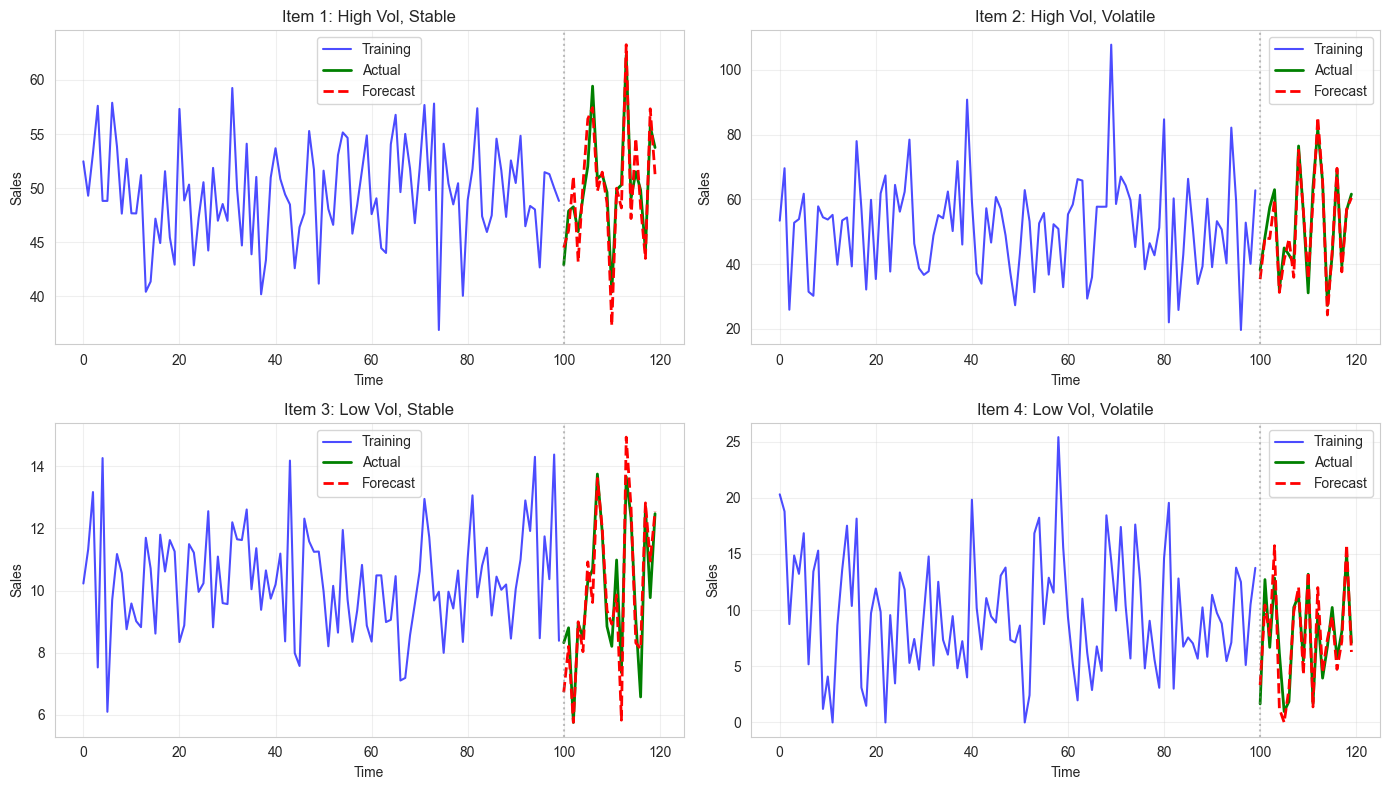

In [4]:
# Visualize the time series
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
axes = axes.flatten()

for i, item in enumerate(items):
    ax = axes[i]
    time_train = np.arange(n_train)
    time_test = np.arange(n_train, n_train + n_test)
    
    ax.plot(time_train, y_train[i], 'b-', label='Training', alpha=0.7)
    ax.plot(time_test, y_test[i], 'g-', label='Actual', linewidth=2)
    ax.plot(time_test, y_pred[i], 'r--', label='Forecast', linewidth=2)
    ax.axvline(x=n_train, color='gray', linestyle=':', alpha=0.5)
    ax.set_title(item)
    ax.set_ylabel('Sales')
    ax.set_xlabel('Time')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 3. Understanding the Scaling Factor

The **scaling factor** is crucial to WRMSSE. It normalizes forecast errors by the natural variability of each series.

**Formula:**
$$\text{scale}_i = \frac{1}{m}\sum_{t=2}^{m+1}(\text{actual}_{t} - \text{actual}_{t-1})^2$$

**Why?** 
- A series that naturally fluctuates a lot (high scale) should not be penalized as heavily for prediction errors
- A series that's very stable (low scale) should be penalized more for the same absolute error
- This creates a "fair" comparison across items with different inherent variability

CALCULATING SCALING FACTORS

Item 1: High Vol, Stable
  - Sample differences (first 5): [-3.17489227e+00  3.92976420e+00  4.37670659e+00 -8.78591616e+00
  8.20888708e-05]
  - Mean squared differences: 42.0300
  - Scale factor: 42.0300

Item 2: High Vol, Volatile
  - Sample differences (first 5): [ 16.1952423  -43.71938983  26.8817564    1.12873404   7.82910116]
  - Mean squared differences: 468.3342
  - Scale factor: 468.3342

Item 3: Low Vol, Stable
  - Sample differences (first 5): [ 1.09722666  1.84777228 -5.64766463  6.74169775 -8.17024235]
  - Mean squared differences: 6.0452
  - Scale factor: 6.0452

Item 4: Low Vol, Volatile
  - Sample differences (first 5): [ -1.52703541 -10.02152495   6.1026755   -1.63097501   3.61627804]
  - Mean squared differences: 45.6630
  - Scale factor: 45.6630


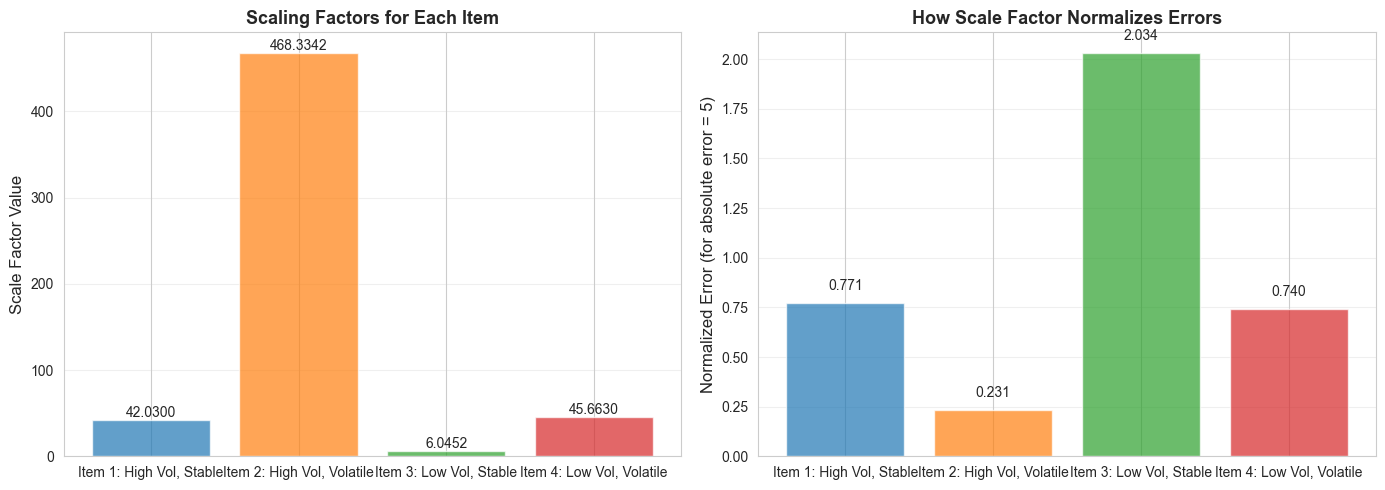


💡 Key insight: Volatile items have higher scale factors.
   Same absolute error is less penalizing for volatile items!


In [5]:
# Calculate scaling factors manually to understand the process
print("=" * 60)
print("CALCULATING SCALING FACTORS")
print("=" * 60)

scale_factors = compute_scale(y_train)

for i, item in enumerate(items):
    # Manual calculation for understanding
    diffs = np.diff(y_train[i])
    squared_diffs = diffs ** 2
    scale = np.mean(squared_diffs)
    
    print(f"\n{item}")
    print(f"  - Sample differences (first 5): {diffs[:5]}")
    print(f"  - Mean squared differences: {scale:.4f}")
    print(f"  - Scale factor: {scale_factors[i]:.4f}")

# Visualize scaling factors
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of scale factors
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
ax1.bar(items, scale_factors, color=colors, alpha=0.7)
ax1.set_ylabel('Scale Factor Value', fontsize=12)
ax1.set_title('Scaling Factors for Each Item', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
for i, (item, scale) in enumerate(zip(items, scale_factors)):
    ax1.text(i, scale + 0.01, f'{scale:.4f}', ha='center', va='bottom')

# Show how scale affects error interpretation
ax2.set_title('How Scale Factor Normalizes Errors', fontsize=13, fontweight='bold')
mock_error = 5  # Same absolute error
normalized_errors = mock_error / np.sqrt(scale_factors)
ax2.bar(items, normalized_errors, color=colors, alpha=0.7)
ax2.set_ylabel('Normalized Error (for absolute error = 5)', fontsize=12)
ax2.grid(True, alpha=0.3, axis='y')
for i, err in enumerate(normalized_errors):
    ax2.text(i, err + 0.05, f'{err:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

print("\n💡 Key insight: Volatile items have higher scale factors.")
print("   Same absolute error is less penalizing for volatile items!")

## 4. Understanding RMSSE (Root Mean Squared Scaled Error)

Now that we have scaling factors, we can compute RMSSE for each item.

**Formula:**
$$\text{RMSSE}_i = \sqrt{\frac{\text{MSE}_i}{\text{scale}_i}} = \sqrt{\frac{\frac{1}{n}\sum_{t=1}^{n}(\text{actual}_t - \text{forecast}_t)^2}{\text{scale}_i}}$$

**What does it mean?**
- RMSSE combines the Mean Squared Error of the forecast with the scaling factor
- If a forecast is perfect (error = 0), then RMSSE = 0
- If a forecast is as bad as the naive forecast, then RMSSE ≈ 1
- RMSSE < 1 means the forecast is better than baseline, > 1 means it's worse

CALCULATING RMSSE (Root Mean Squared Scaled Error)

Item 1: High Vol, Stable
  - MSE: 4.3994
  - Scale: 42.0300
  - RMSSE: 0.3235
    ✓ Better than naive forecast (RMSSE < 1)

Item 2: High Vol, Volatile
  - MSE: 11.7817
  - Scale: 468.3342
  - RMSSE: 0.1586
    ✓ Better than naive forecast (RMSSE < 1)

Item 3: Low Vol, Stable
  - MSE: 0.7588
  - Scale: 6.0452
  - RMSSE: 0.3543
    ✓ Better than naive forecast (RMSSE < 1)

Item 4: Low Vol, Volatile
  - MSE: 2.8117
  - Scale: 45.6630
  - RMSSE: 0.2481
    ✓ Better than naive forecast (RMSSE < 1)


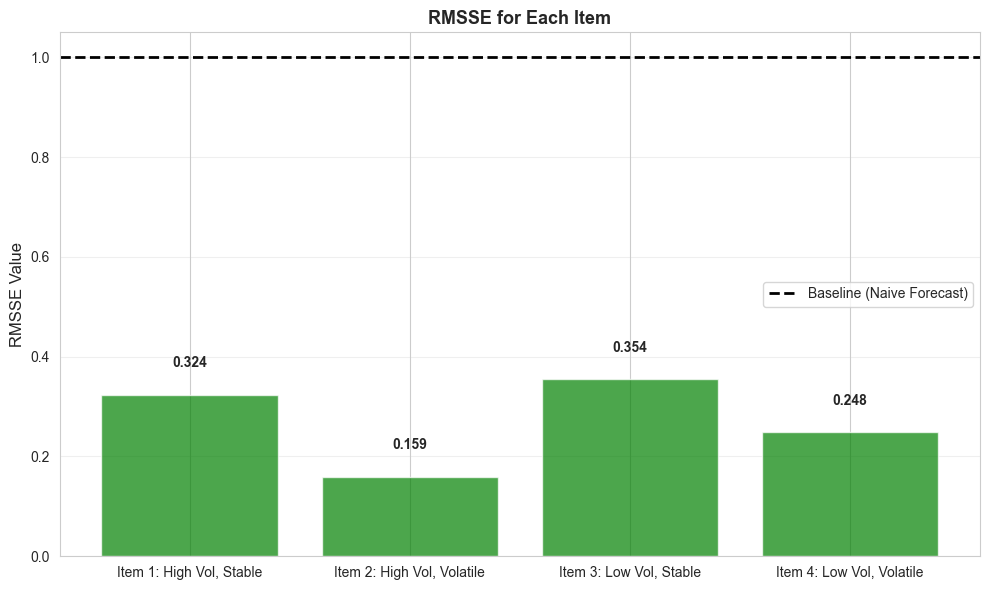


💡 Key insight: RMSSE balances absolute error with inherent series volatility.


In [6]:
# Calculate RMSSE for each item
print("=" * 60)
print("CALCULATING RMSSE (Root Mean Squared Scaled Error)")
print("=" * 60)

rmsse_values = compute_rmsse(y_test, y_pred, scale_factors)

for i, item in enumerate(items):
    mse = np.mean((y_test[i] - y_pred[i]) ** 2)
    rmsse = np.sqrt(mse / scale_factors[i])
    
    print(f"\n{item}")
    print(f"  - MSE: {mse:.4f}")
    print(f"  - Scale: {scale_factors[i]:.4f}")
    print(f"  - RMSSE: {rmsse:.4f}")
    
    # Baseline interpretation
    if rmsse < 1:
        print(f"    ✓ Better than naive forecast (RMSSE < 1)")
    elif rmsse > 1:
        print(f"    ✗ Worse than naive forecast (RMSSE > 1)")
    else:
        print(f"    ≈ Same as naive forecast (RMSSE ≈ 1)")

# Visualize RMSSE values
fig, ax = plt.subplots(figsize=(10, 6))

colors_rmsse = ['green' if r < 1 else 'red' for r in rmsse_values]
bars = ax.bar(items, rmsse_values, color=colors_rmsse, alpha=0.7)
ax.axhline(y=1, color='black', linestyle='--', linewidth=2, label='Baseline (Naive Forecast)')
ax.set_ylabel('RMSSE Value', fontsize=12)
ax.set_title('RMSSE for Each Item', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.legend()

for i, rmsse in enumerate(rmsse_values):
    ax.text(i, rmsse + 0.05, f'{rmsse:.3f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Key insight: RMSSE balances absolute error with inherent series volatility.")

## 5. Understanding the Weighting Mechanism

WMSSE stands for "Weighted" because not all items deserve equal importance in the final score.

**Formula:**
$$\text{Weight}_i = \frac{\sum_{t=1}^{m} \text{actual}_{i,t}}{\sum_{i=1}^{N}\sum_{t=1}^{m} \text{actual}_{i,t}}$$

**Why?**
- High-volume items deserve more weight in the evaluation
- A 10% error on Item 1 (high volume) affects business more than 10% error on Item 3 (low volume)
- In retail, selling 1000 units with 1% error is more important than selling 10 units with 5% error

CALCULATING WEIGHTS (based on sales volume)

Item 1: High Vol, Stable
  - Total sales: 4948.08
  - Weight: 0.4085 (40.85%)

Item 2: High Vol, Volatile
  - Total sales: 5167.81
  - Weight: 0.4266 (42.66%)

Item 3: Low Vol, Stable
  - Total sales: 1028.97
  - Weight: 0.0849 (8.49%)

Item 4: Low Vol, Volatile
  - Total sales: 968.87
  - Weight: 0.0800 (8.00%)


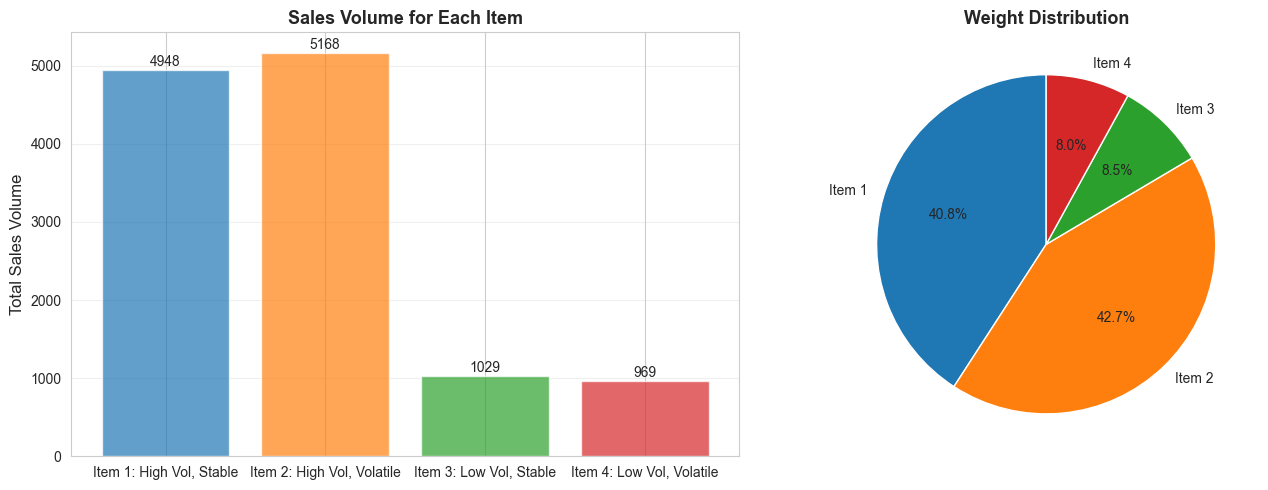


💡 Key insight: High-volume items get higher weights in WRMSSE calculation.


In [7]:
# Calculate weights
print("=" * 60)
print("CALCULATING WEIGHTS (based on sales volume)")
print("=" * 60)

weights = compute_weights(y_train)

total_sales = np.sum(y_train, axis=1)

for i, item in enumerate(items):
    print(f"\n{item}")
    print(f"  - Total sales: {total_sales[i]:.2f}")
    print(f"  - Weight: {weights[i]:.4f} ({weights[i]*100:.2f}%)")

# Visualize weights
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar plot of sales volume
ax1.bar(items, total_sales, color=colors, alpha=0.7)
ax1.set_ylabel('Total Sales Volume', fontsize=12)
ax1.set_title('Sales Volume for Each Item', fontsize=13, fontweight='bold')
ax1.grid(True, alpha=0.3, axis='y')
for i, sales in enumerate(total_sales):
    ax1.text(i, sales + 10, f'{sales:.0f}', ha='center', va='bottom')

# Pie chart of weights
ax2.pie(weights, labels=[f"Item {i+1}" for i in range(len(items))], 
        autopct='%1.1f%%', colors=colors, startangle=90)
ax2.set_title('Weight Distribution', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n💡 Key insight: High-volume items get higher weights in WRMSSE calculation.")

## 6. Calculate WRMSSE Step by Step

Now we combine everything! WRMSSE is the weighted average of individual RMSSE scores.

**Formula:**
$$\text{WRMSSE} = \sqrt{\frac{\sum_{i=1}^{N} \text{Weight}_i \times \text{RMSSE}_i^2}{\sum_{i=1}^{N} \text{Weight}_i}}$$

**Interpretation:**
- WRMSSE < 1: Your forecast is better than using naive forecast for all items
- WRMSSE = 1: Your forecast is as good as the naive baseline
- WRMSSE > 1: Your forecast is worse than the naive baseline

In [8]:
# Calculate WRMSSE step by step
print("=" * 80)
print("CALCULATING WRMSSE (Step-by-Step Breakdown)")
print("=" * 80)

# Step 1: Calculate weighted RMSSE squared
weighted_rmsse_squared = weights * (rmsse_values ** 2)

print("\nStep 1: Calculate individual RMSSE values")
print(f"{'Item':<30} {'RMSSE':<10} {'Weight':<10}")
print("-" * 50)
for i, item in enumerate(items):
    print(f"{item:<30} {rmsse_values[i]:<10.6f} {weights[i]:<10.6f}")

print("\nStep 2: Calculate weighted RMSSE squared")
print(f"{'Item':<30} {'RMSSE²':<12} {'Weight':<10} {'Weight×RMSSE²':<15}")
print("-" * 67)
for i, item in enumerate(items):
    print(f"{item:<30} {rmsse_values[i]**2:<12.6f} {weights[i]:<10.6f} {weighted_rmsse_squared[i]:<15.6f}")

print(f"\n{'Sum of (Weight × RMSSE²):':<45} {np.sum(weighted_rmsse_squared):.6f}")
print(f"{'Sum of Weights:':<45} {np.sum(weights):.6f}")

# Step 3: Final WRMSSE
wrmsse_score = np.sqrt(np.sum(weighted_rmsse_squared) / np.sum(weights))

print(f"\nStep 3: Calculate final WRMSSE")
print(f"WRMSSE = sqrt({np.sum(weighted_rmsse_squared):.6f} / {np.sum(weights):.6f})")
print(f"WRMSSE = {wrmsse_score:.6f}")

# Verify with our function
wrmsse_func = wrmsse(y_test, y_pred, y_train)
print(f"\nVerification with wrmsse() function: {wrmsse_func:.6f}")
assert np.isclose(wrmsse_score, wrmsse_func), "Calculation mismatch!"
print("✓ Calculations match!")

CALCULATING WRMSSE (Step-by-Step Breakdown)

Step 1: Calculate individual RMSSE values
Item                           RMSSE      Weight    
--------------------------------------------------
Item 1: High Vol, Stable       0.323533   0.408469  
Item 2: High Vol, Volatile     0.158609   0.426608  
Item 3: Low Vol, Stable        0.354289   0.084942  
Item 4: Low Vol, Volatile      0.248145   0.079981  

Step 2: Calculate weighted RMSSE squared
Item                           RMSSE²       Weight     Weight×RMSSE²  
-------------------------------------------------------------------
Item 1: High Vol, Stable       0.104674     0.408469   0.042756       
Item 2: High Vol, Volatile     0.025157     0.426608   0.010732       
Item 3: Low Vol, Stable        0.125520     0.084942   0.010662       
Item 4: Low Vol, Volatile      0.061576     0.079981   0.004925       

Sum of (Weight × RMSSE²):                     0.069075
Sum of Weights:                               1.000000

Step 3: Calculate fi

## 7. Visualize WRMSSE Components

Let's create visualizations showing how all components contribute to the final score.

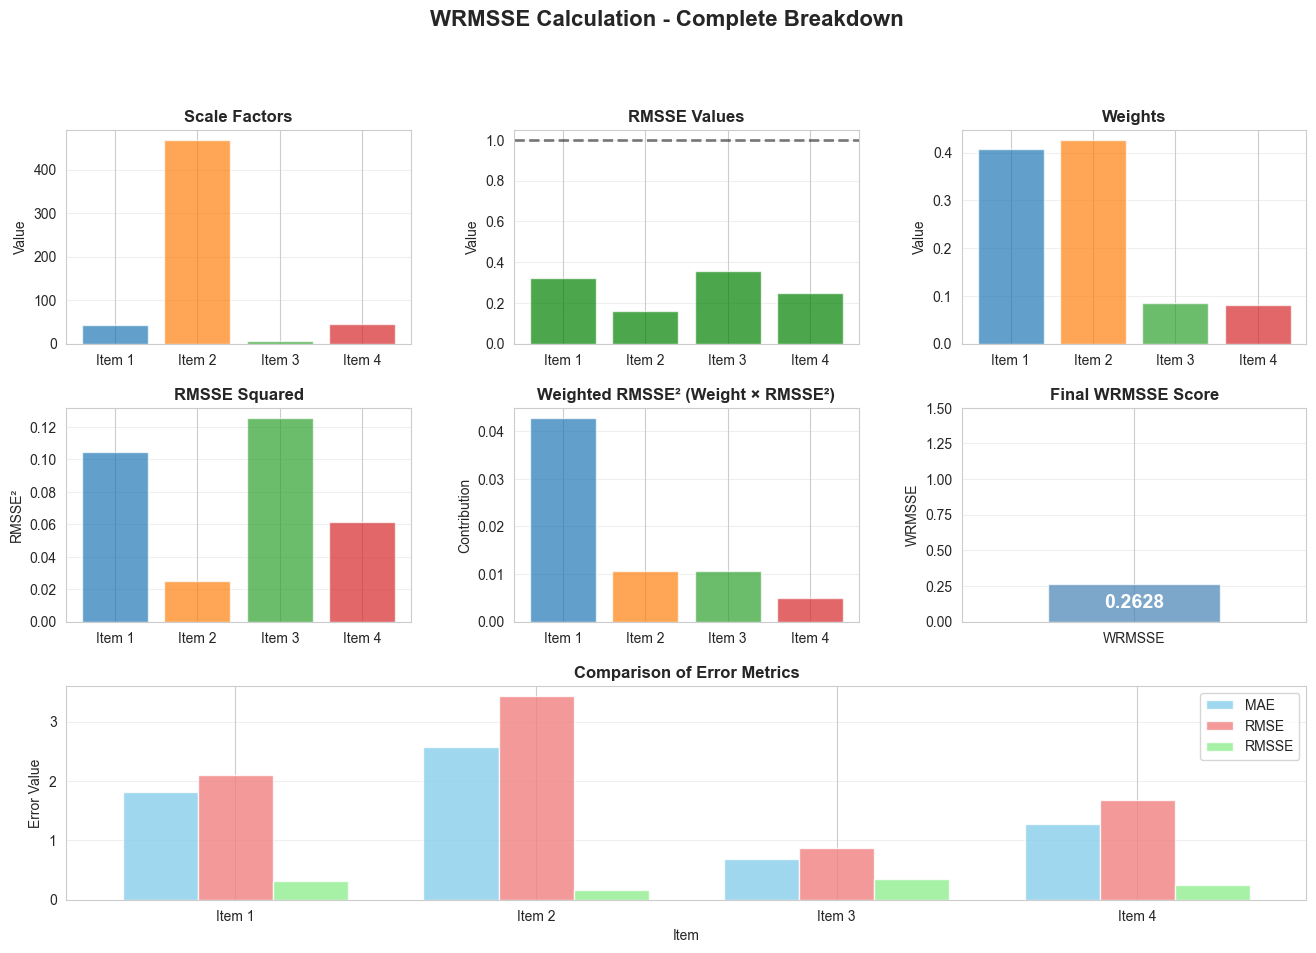


SUMMARY
WRMSSE Score: 0.262821
✓ Your forecast is BETTER than the naive baseline!


In [9]:
# Create comprehensive visualization
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.3, wspace=0.3)

# Row 1: Scale factors, RMSSE, Weights
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(range(len(items)), scale_factors, color=colors, alpha=0.7)
ax1.set_ylabel('Value')
ax1.set_title('Scale Factors', fontweight='bold')
ax1.set_xticks(range(len(items)))
ax1.set_xticklabels([f'Item {i+1}' for i in range(len(items))])
ax1.grid(True, alpha=0.3, axis='y')

ax2 = fig.add_subplot(gs[0, 1])
rmsse_colors = ['green' if r < 1 else 'red' for r in rmsse_values]
ax2.bar(range(len(items)), rmsse_values, color=rmsse_colors, alpha=0.7)
ax2.axhline(y=1, color='black', linestyle='--', linewidth=2, alpha=0.5)
ax2.set_ylabel('Value')
ax2.set_title('RMSSE Values', fontweight='bold')
ax2.set_xticks(range(len(items)))
ax2.set_xticklabels([f'Item {i+1}' for i in range(len(items))])
ax2.grid(True, alpha=0.3, axis='y')

ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(range(len(items)), weights, color=colors, alpha=0.7)
ax3.set_ylabel('Value')
ax3.set_title('Weights', fontweight='bold')
ax3.set_xticks(range(len(items)))
ax3.set_xticklabels([f'Item {i+1}' for i in range(len(items))])
ax3.grid(True, alpha=0.3, axis='y')

# Row 2: RMSSE squared, Weighted contribution
ax4 = fig.add_subplot(gs[1, 0])
rmsse_squared = rmsse_values ** 2
ax4.bar(range(len(items)), rmsse_squared, color=colors, alpha=0.7)
ax4.set_ylabel('RMSSE²')
ax4.set_title('RMSSE Squared', fontweight='bold')
ax4.set_xticks(range(len(items)))
ax4.set_xticklabels([f'Item {i+1}' for i in range(len(items))])
ax4.grid(True, alpha=0.3, axis='y')

ax5 = fig.add_subplot(gs[1, 1])
ax5.bar(range(len(items)), weighted_rmsse_squared, color=colors, alpha=0.7)
ax5.set_ylabel('Contribution')
ax5.set_title('Weighted RMSSE² (Weight × RMSSE²)', fontweight='bold')
ax5.set_xticks(range(len(items)))
ax5.set_xticklabels([f'Item {i+1}' for i in range(len(items))])
ax5.grid(True, alpha=0.3, axis='y')

# Stacked contribution
ax6 = fig.add_subplot(gs[1, 2])
ax6.bar([0], [wrmsse_score], color='steelblue', alpha=0.7, width=0.5)
ax6.set_ylabel('WRMSSE')
ax6.set_title('Final WRMSSE Score', fontweight='bold')
ax6.set_xlim(-0.5, 0.5)
ax6.set_xticks([0])
ax6.set_xticklabels(['WRMSSE'])
ax6.set_ylim(0, max(1.5, wrmsse_score * 1.3))
ax6.text(0, wrmsse_score/2, f'{wrmsse_score:.4f}', ha='center', va='center', 
         fontsize=14, fontweight='bold', color='white')
ax6.grid(True, alpha=0.3, axis='y')

# Row 3: Error analysis
ax7 = fig.add_subplot(gs[2, :])
x_pos = np.arange(len(items))
width = 0.25

bars1 = ax7.bar(x_pos - width, np.abs(y_test - y_pred).mean(axis=1), 
                width, label='MAE', color='skyblue', alpha=0.8)
bars2 = ax7.bar(x_pos, np.sqrt(np.mean((y_test - y_pred)**2, axis=1)), 
                width, label='RMSE', color='lightcoral', alpha=0.8)
bars3 = ax7.bar(x_pos + width, rmsse_values, 
                width, label='RMSSE', color='lightgreen', alpha=0.8)

ax7.set_xlabel('Item')
ax7.set_ylabel('Error Value')
ax7.set_title('Comparison of Error Metrics', fontweight='bold')
ax7.set_xticks(x_pos)
ax7.set_xticklabels([f'Item {i+1}' for i in range(len(items))])
ax7.legend()
ax7.grid(True, alpha=0.3, axis='y')

plt.suptitle('WRMSSE Calculation - Complete Breakdown', fontsize=16, fontweight='bold', y=1.00)
plt.show()

print("\n" + "="*80)
print("SUMMARY")
print("="*80)
print(f"WRMSSE Score: {wrmsse_score:.6f}")
if wrmsse_score < 1:
    print(f"✓ Your forecast is BETTER than the naive baseline!")
else:
    print(f"✗ Your forecast is WORSE than the naive baseline.")
print("="*80)

## 8. Compare Different Forecasts Using WRMSSE

Now let's create different forecast scenarios to see how WRMSSE distinguishes between them.

COMPARING DIFFERENT FORECAST SCENARIOS
Naive Forecast                 WRMSSE = 0.882284
Good Forecast                  WRMSSE = 0.262821
Bad Forecast                   WRMSSE = 3.820008
Perfect Forecast               WRMSSE = 0.000000
Biased Forecast (30% high)     WRMSSE = 1.615771


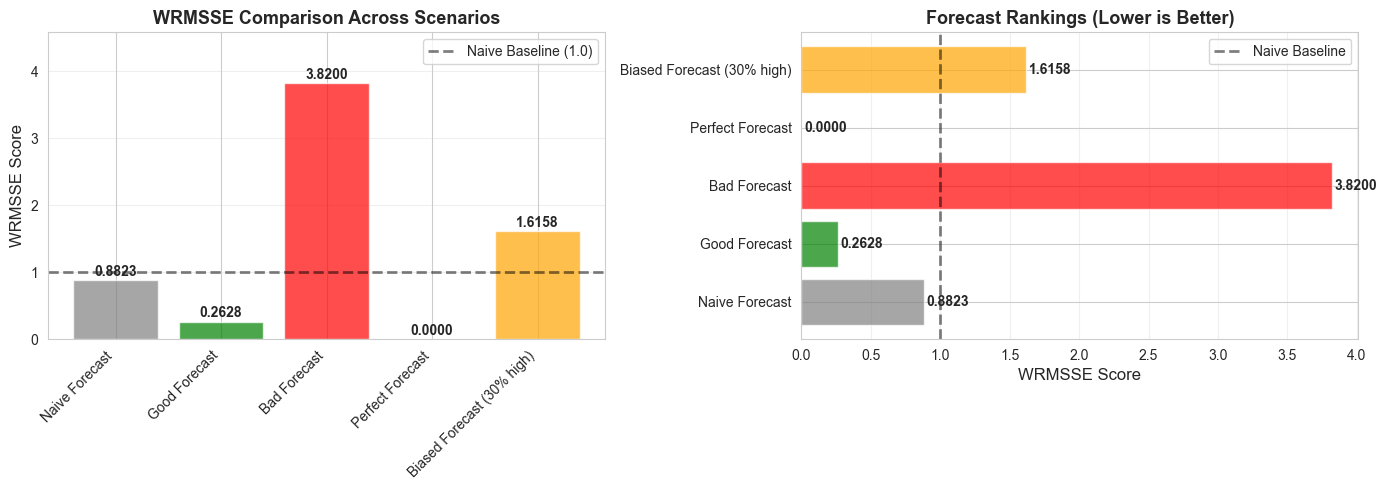


KEY TAKEAWAYS
1. Perfect forecast has WRMSSE ≈ 0 (best possible)
2. Naive forecast has WRMSSE ≈ 1 (baseline)
3. Good forecasts have WRMSSE < 1
4. Bad forecasts have WRMSSE > 1
5. WRMSSE rewards beating the naive baseline consistently across all items


In [10]:
# Create different forecast scenarios
print("="*80)
print("COMPARING DIFFERENT FORECAST SCENARIOS")
print("="*80)

# Scenario 1: Naive forecast (predict last training value)
y_pred_naive = np.tile(y_train[:, -1:], (1, n_test))

# Scenario 2: Good forecast (our current prediction)
y_pred_good = y_pred.copy()

# Scenario 3: Bad forecast (random predictions)
y_pred_bad = np.random.uniform(0, 30, size=(len(items), n_test))

# Scenario 4: Perfect forecast
y_pred_perfect = y_test.copy()

# Scenario 5: Biased forecast (consistently overestimate)
y_pred_biased = y_test * 1.3  # 30% overestimate

# Calculate WRMSSE for each scenario
scenarios = {
    'Naive Forecast': y_pred_naive,
    'Good Forecast': y_pred_good,
    'Bad Forecast': y_pred_bad,
    'Perfect Forecast': y_pred_perfect,
    'Biased Forecast (30% high)': y_pred_biased,
}

wrmsse_scores = {}
for scenario_name, predictions in scenarios.items():
    score = wrmsse(y_test, predictions, y_train)
    wrmsse_scores[scenario_name] = score
    print(f"{scenario_name:<30} WRMSSE = {score:.6f}")

# Visualize comparison
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart
scenario_names = list(wrmsse_scores.keys())
scores = list(wrmsse_scores.values())
colors_scenarios = ['gray', 'green', 'red', 'gold', 'orange']
bars = ax1.bar(scenario_names, scores, color=colors_scenarios, alpha=0.7)
ax1.axhline(y=1, color='black', linestyle='--', linewidth=2, alpha=0.5, label='Naive Baseline (1.0)')
ax1.set_ylabel('WRMSSE Score', fontsize=12)
ax1.set_title('WRMSSE Comparison Across Scenarios', fontsize=13, fontweight='bold')
ax1.set_ylim(0, max(scores) * 1.2)
ax1.legend()
ax1.grid(True, alpha=0.3, axis='y')
plt.setp(ax1.xaxis.get_majorticklabels(), rotation=45, ha='right')

for i, (bar, score) in enumerate(zip(bars, scores)):
    ax1.text(bar.get_x() + bar.get_width()/2, score + 0.02, 
             f'{score:.4f}', ha='center', va='bottom', fontweight='bold')

# Ranking
ax2.barh(scenario_names, scores, color=colors_scenarios, alpha=0.7)
ax2.axvline(x=1, color='black', linestyle='--', linewidth=2, alpha=0.5, label='Naive Baseline')
ax2.set_xlabel('WRMSSE Score', fontsize=12)
ax2.set_title('Forecast Rankings (Lower is Better)', fontsize=13, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3, axis='x')

for i, (scenario, score) in enumerate(wrmsse_scores.items()):
    ax2.text(score + 0.02, i, f'{score:.4f}', va='center', fontweight='bold')

plt.tight_layout()
plt.show()

print("\n" + "="*80)
print("KEY TAKEAWAYS")
print("="*80)
print("1. Perfect forecast has WRMSSE ≈ 0 (best possible)")
print("2. Naive forecast has WRMSSE ≈ 1 (baseline)")
print("3. Good forecasts have WRMSSE < 1")
print("4. Bad forecasts have WRMSSE > 1")
print("5. WRMSSE rewards beating the naive baseline consistently across all items")
print("="*80)

## Conclusion and Practical Insights

### Why WRMSSE is a Good Metric:

1. **Fair Comparison**: Scales errors by series variability, treating volatile and stable series fairly
2. **Business Aligned**: Weights errors by sales importance, prioritizing high-volume items
3. **Baseline Aware**: Compares forecast quality to naive baseline (RMSSE = 1 ≈ naive forecast)
4. **Penalizes Bias**: Detects systematic under/over-forecasting through squared errors
5. **Aggregates Well**: Combines multiple series into a single interpretable score

### How to Improve WRMSSE:

- **Reduce forecast error** on all items, but especially on high-volume items (bigger weight)
- **Better handle volatility** by modeling temporal patterns and seasonality
- **Consistency matters** - minimizing large errors is better than having mixed results
- Focus on beating the **naive forecast baseline** (RMSSE = 1) for each series

### When Using WRMSSE:

✓ **Use for**: M5 competition, retail forecasting, aggregated multi-series evaluation
✗ **Be careful**: Don't rely solely on WRMSSE for business decisions (also check MAE, MAPE, and business impact)